In [1]:
import cv2
import torch

from depth_anything_v2.dpt import DepthAnythingV2

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
    'vitg': {'encoder': 'vitg', 'features': 384, 'out_channels': [1536, 1536, 1536, 1536]}
}

encoder = 'vitl' # or 'vits', 'vitb', 'vitg'

model = DepthAnythingV2(**model_configs[encoder])
model.load_state_dict(torch.load(f'checkpoints/depth_anything_v2_{encoder}.pth', map_location='cpu'))
model = model.to(DEVICE).eval()

raw_img = cv2.imread('./Test_IMG.jpg')
depth = model.infer_image(raw_img) # HxW raw depth map in numpy

xFormers not available
xFormers not available


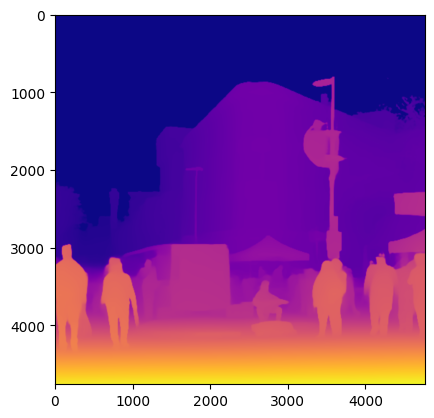

In [2]:
import matplotlib.pyplot as plt
plt.imshow(depth, cmap='plasma')

In [10]:
torch.save(torch.tensor(depth),'depth_tensor.pt')

In [8]:
torch.tensor(depth)

tensor([[  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
        ...,
        [504.6457, 504.5870, 504.5284,  ..., 521.2631, 521.3457, 521.4284],
        [504.9371, 504.8865, 504.8359,  ..., 521.6757, 521.7703, 521.8649],
        [505.2284, 505.1860, 505.1436,  ..., 522.0883, 522.1948, 522.3014]])